## Setup

In [7]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optuna
from scipy.stats import gaussian_kde

mpl.rcParams["figure.dpi"] = 300

LAUNCH_DIR = "out/default"

In [8]:
studies_dir = Path("../") / LAUNCH_DIR
studies_files = [f.name for f in studies_dir.iterdir()]
studies = [
    optuna.load_study(study_name=study.split(".")[0], storage=f"sqlite:///{studies_dir / study}")
    for study in studies_files
]

In [9]:
studies[0].trials_dataframe().head()

,number,value,datetime_start,datetime_complete,duration,params_batch_size_exp,params_conv_channels_mult,params_conv_layers_spec,params_kl_max,params_lr,params_n_fusion_layers,user_attrs_accuracies,user_attrs_accuracy_p25,user_attrs_accuracy_p75,state
0,0,0.921875,2026-03-18 09:55:24.820181,2026-03-18 10:13:39.443279,0 days 00:18:14.623098,7,4,0,17.254717,0.003575,3,"{'958682846': 0.8666666666666667, '1051802512'...",0.911979,0.930208,COMPLETE
1,1,0.850000,2026-03-18 10:13:39.570892,2026-03-18 10:28:22.972150,0 days 00:14:43.401258,5,4,0,1.063607,0.011115,3,"{'478163327': 0.8541666666666666, '1051802512'...",0.811979,0.870833,COMPLETE
2,2,0.936458,2026-03-18 10:28:23.082597,2026-03-18 10:55:41.643509,0 days 00:27:18.560912,7,3,3,2.392753,0.004345,2,"{'107420369': 0.8729166666666667, '1051802512'...",0.905729,0.959375,COMPLETE
3,3,0.851042,2026-03-18 10:55:41.769080,2026-03-18 11:50:43.604551,0 days 00:55:01.835471,7,5,3,5.898602,0.005749,1,"{'478163327': 0.825, '1051802512': 0.879166666...",0.813542,0.883854,COMPLETE
4,4,NaN,2026-03-18 11:50:43.722983,2026-03-18 11:54:21.430296,0 days 00:03:37.707313,7,3,2,1.339906,0.002818,3,NaN,NaN,NaN,FAIL



## Plots

### Trial Outcomes

In [10]:
study = studies[0].trials_dataframe()
study["params_batch_size"] = study["params_batch_size_exp"].apply(lambda x: 2 ** x)
study["params_conv_channels"]= study["params_conv_channels_mult"].apply(lambda x: 8 * x)

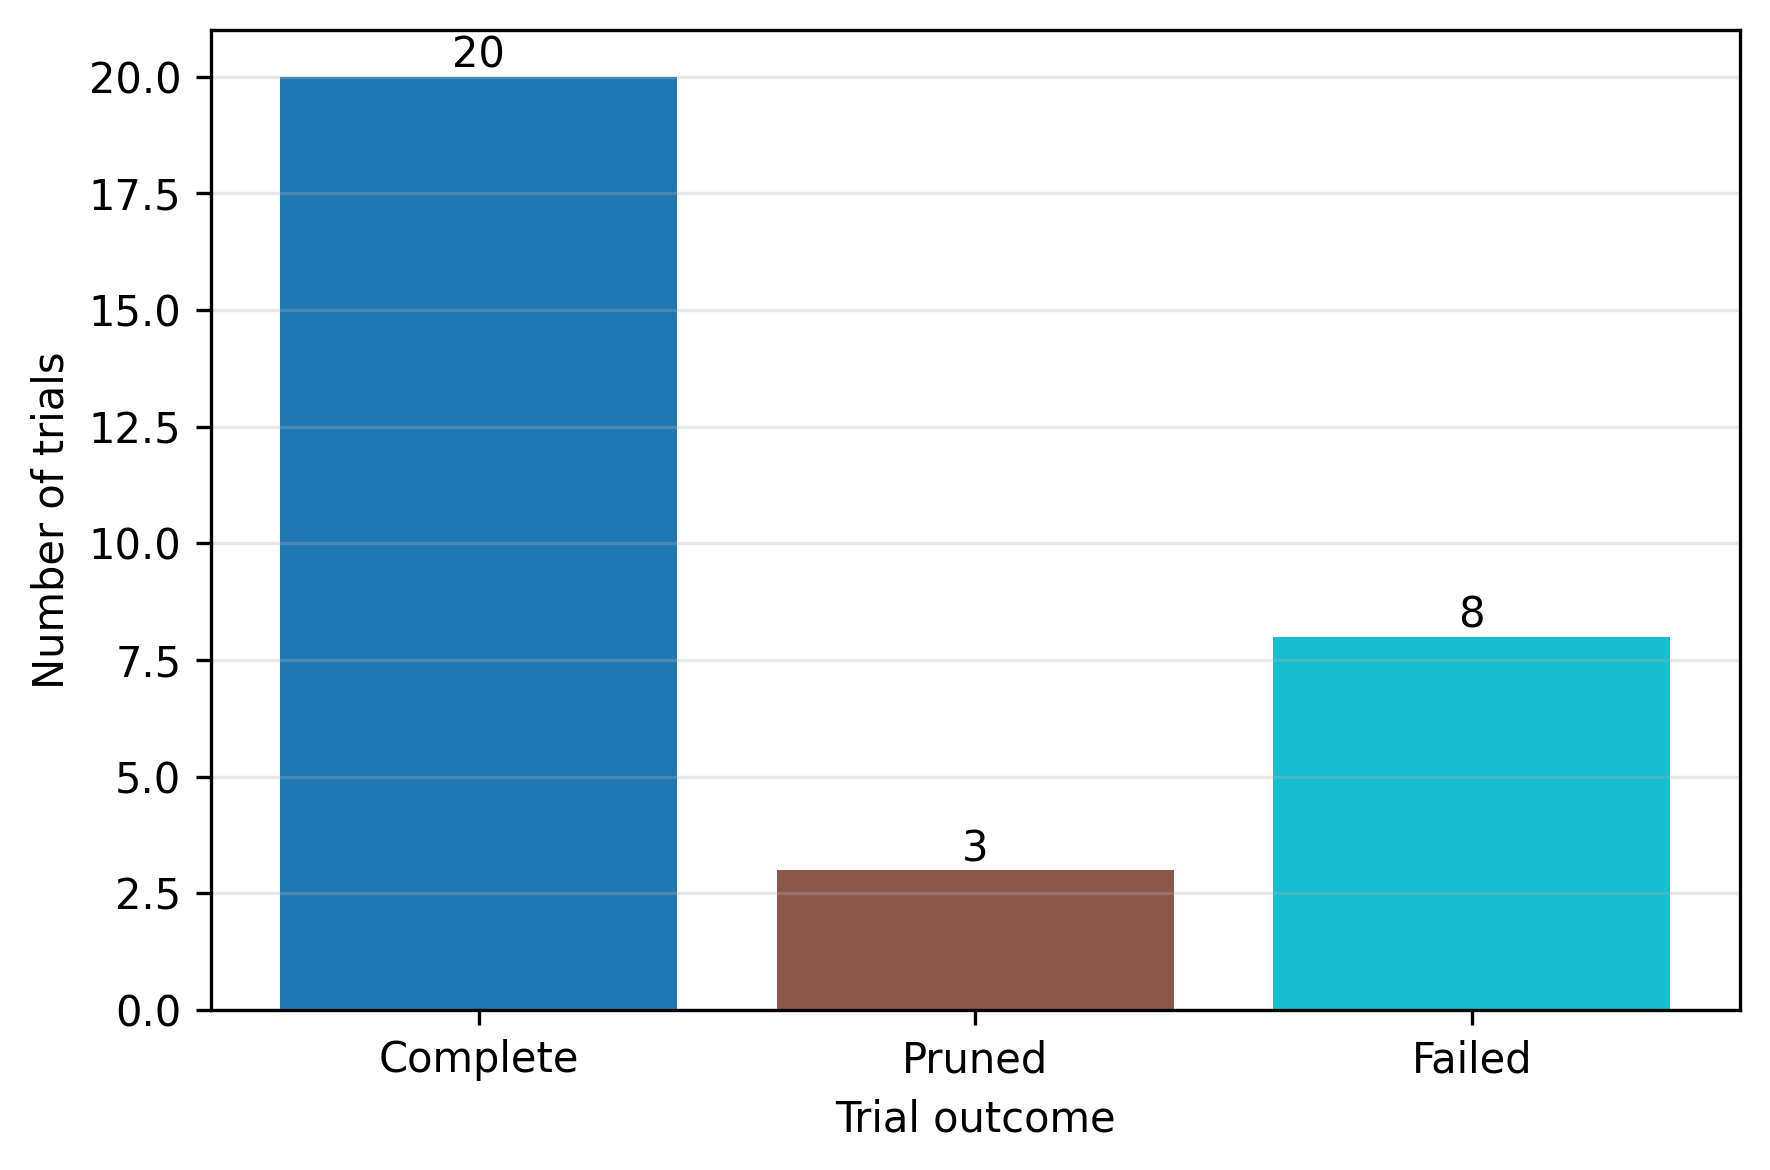

In [11]:
counts = {
    "Complete": study[study["state"] == "COMPLETE"].shape[0],
    "Pruned": study[study["state"] == "PRUNED"].shape[0],
    "Failed": study[study["state"] == "FAIL"].shape[0],
}

plt.figure(figsize=(6, 4))
colors = plt.colormaps["tab10"](np.linspace(0, 1, len(counts)))
bars = plt.bar(list(counts.keys()), list(counts.values()), color=colors)
plt.xlabel("Trial outcome")
plt.ylabel("Number of trials")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h, f"{int(h)}", ha="center", va="bottom")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Accuracy Distribution

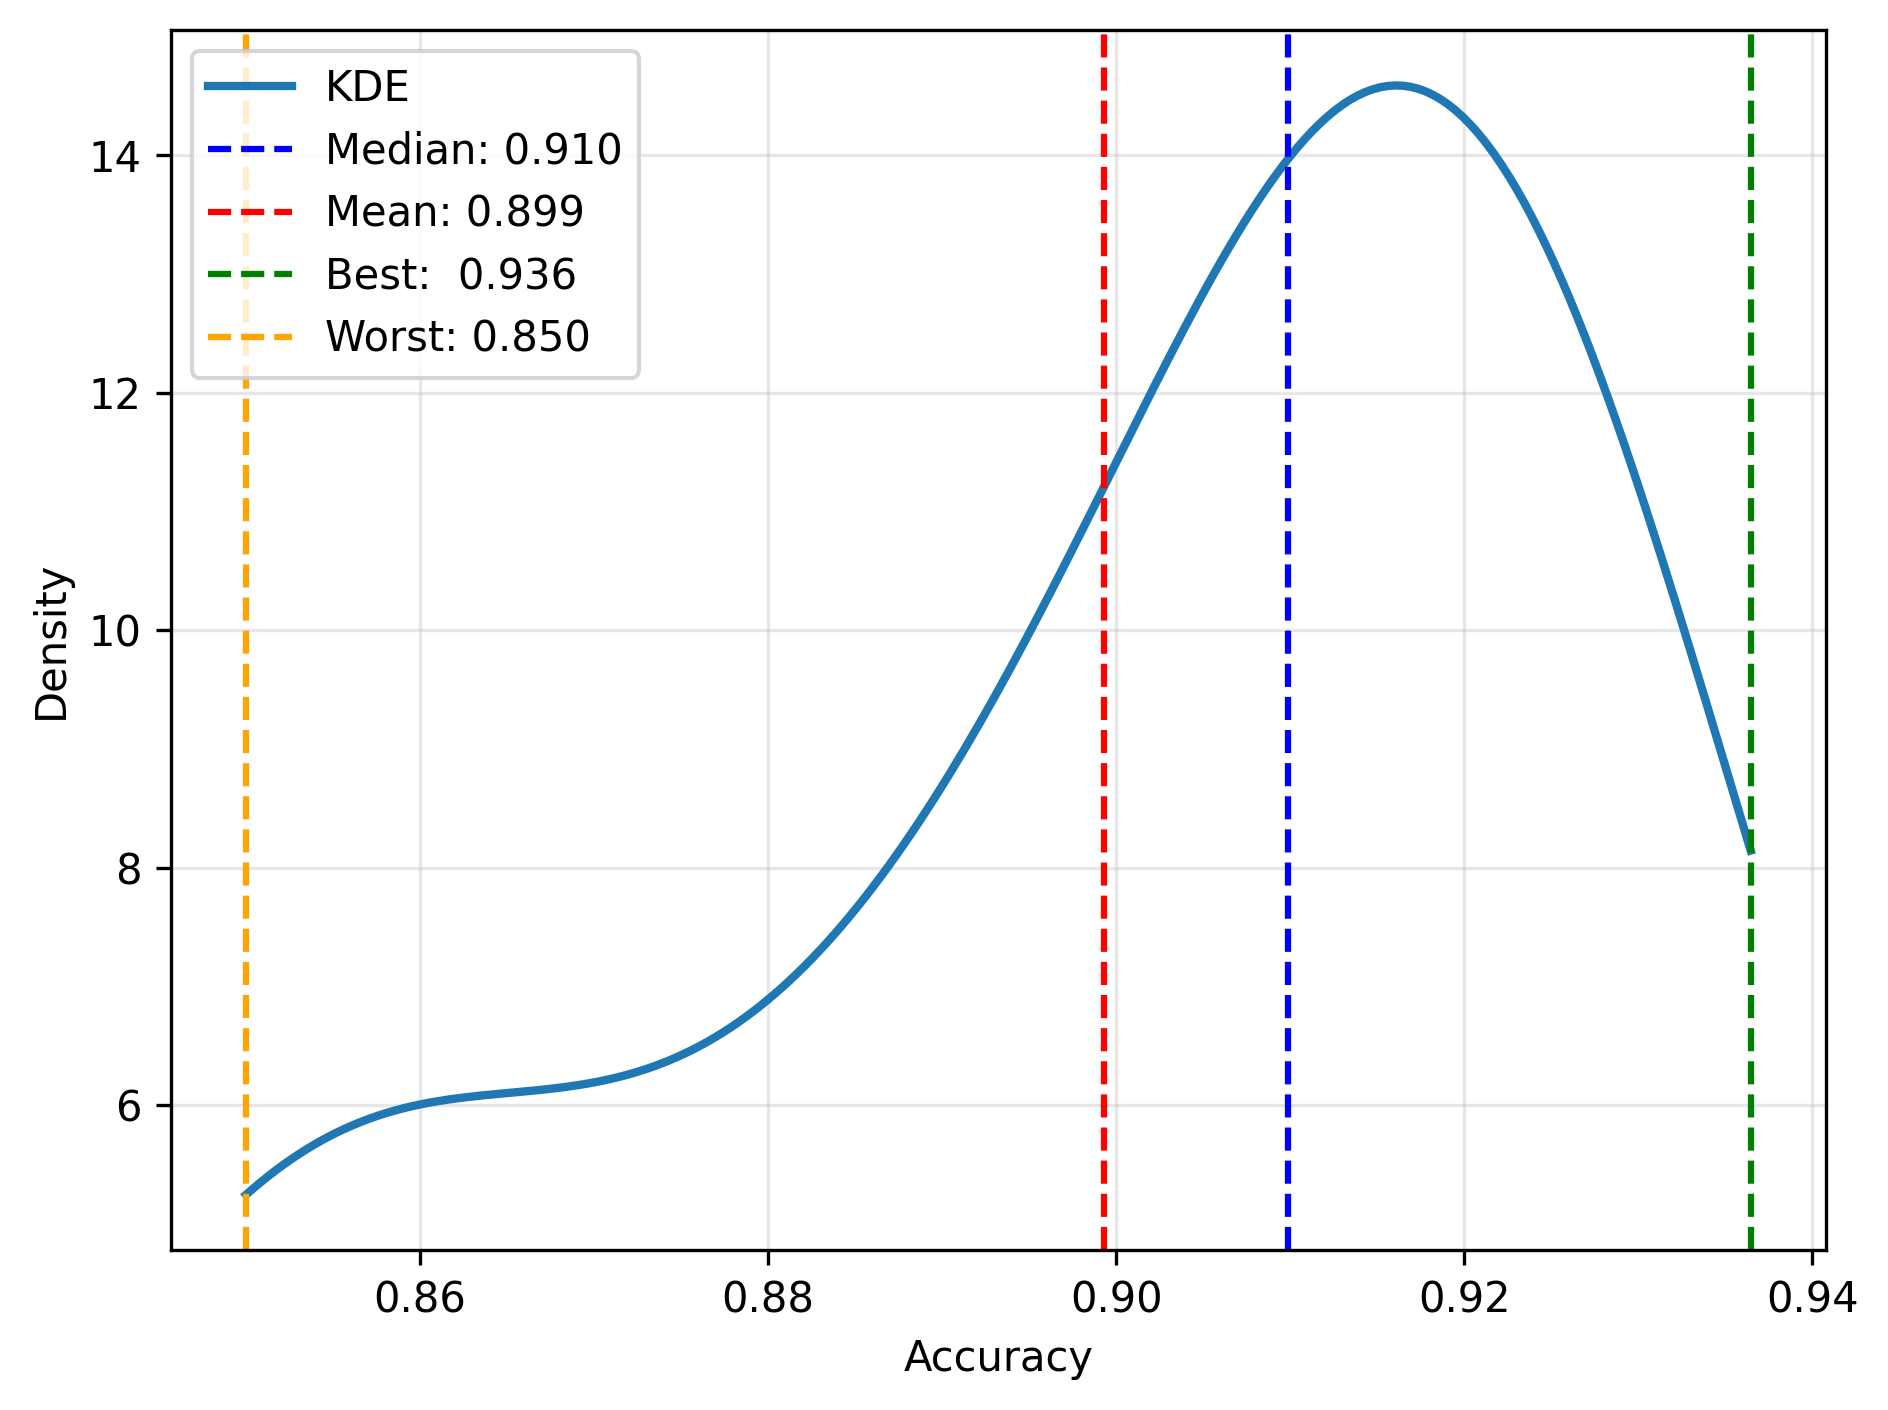

In [12]:
completed = study[study["state"] == "COMPLETE"]["value"].copy().dropna()

kde = gaussian_kde(completed)
x = np.linspace(completed.min(), completed.max(), 200)

plt.plot(x, kde(x), linewidth=2, label="KDE")
plt.axvline(completed.median(), color="blue", linestyle="--", label=f"Median: {completed.median():.3f}")
plt.axvline(completed.mean(), color="red", linestyle="--", label=f"Mean: {completed.mean():.3f}")
plt.axvline(completed.max(), color="green", linestyle="--", label=f"Best:  {completed.max():.3f}")
plt.axvline(completed.min(), color="orange", linestyle="--", label=f"Worst: {completed.min():.3f}")
plt.xlabel("Accuracy")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Hyperparameter Importance

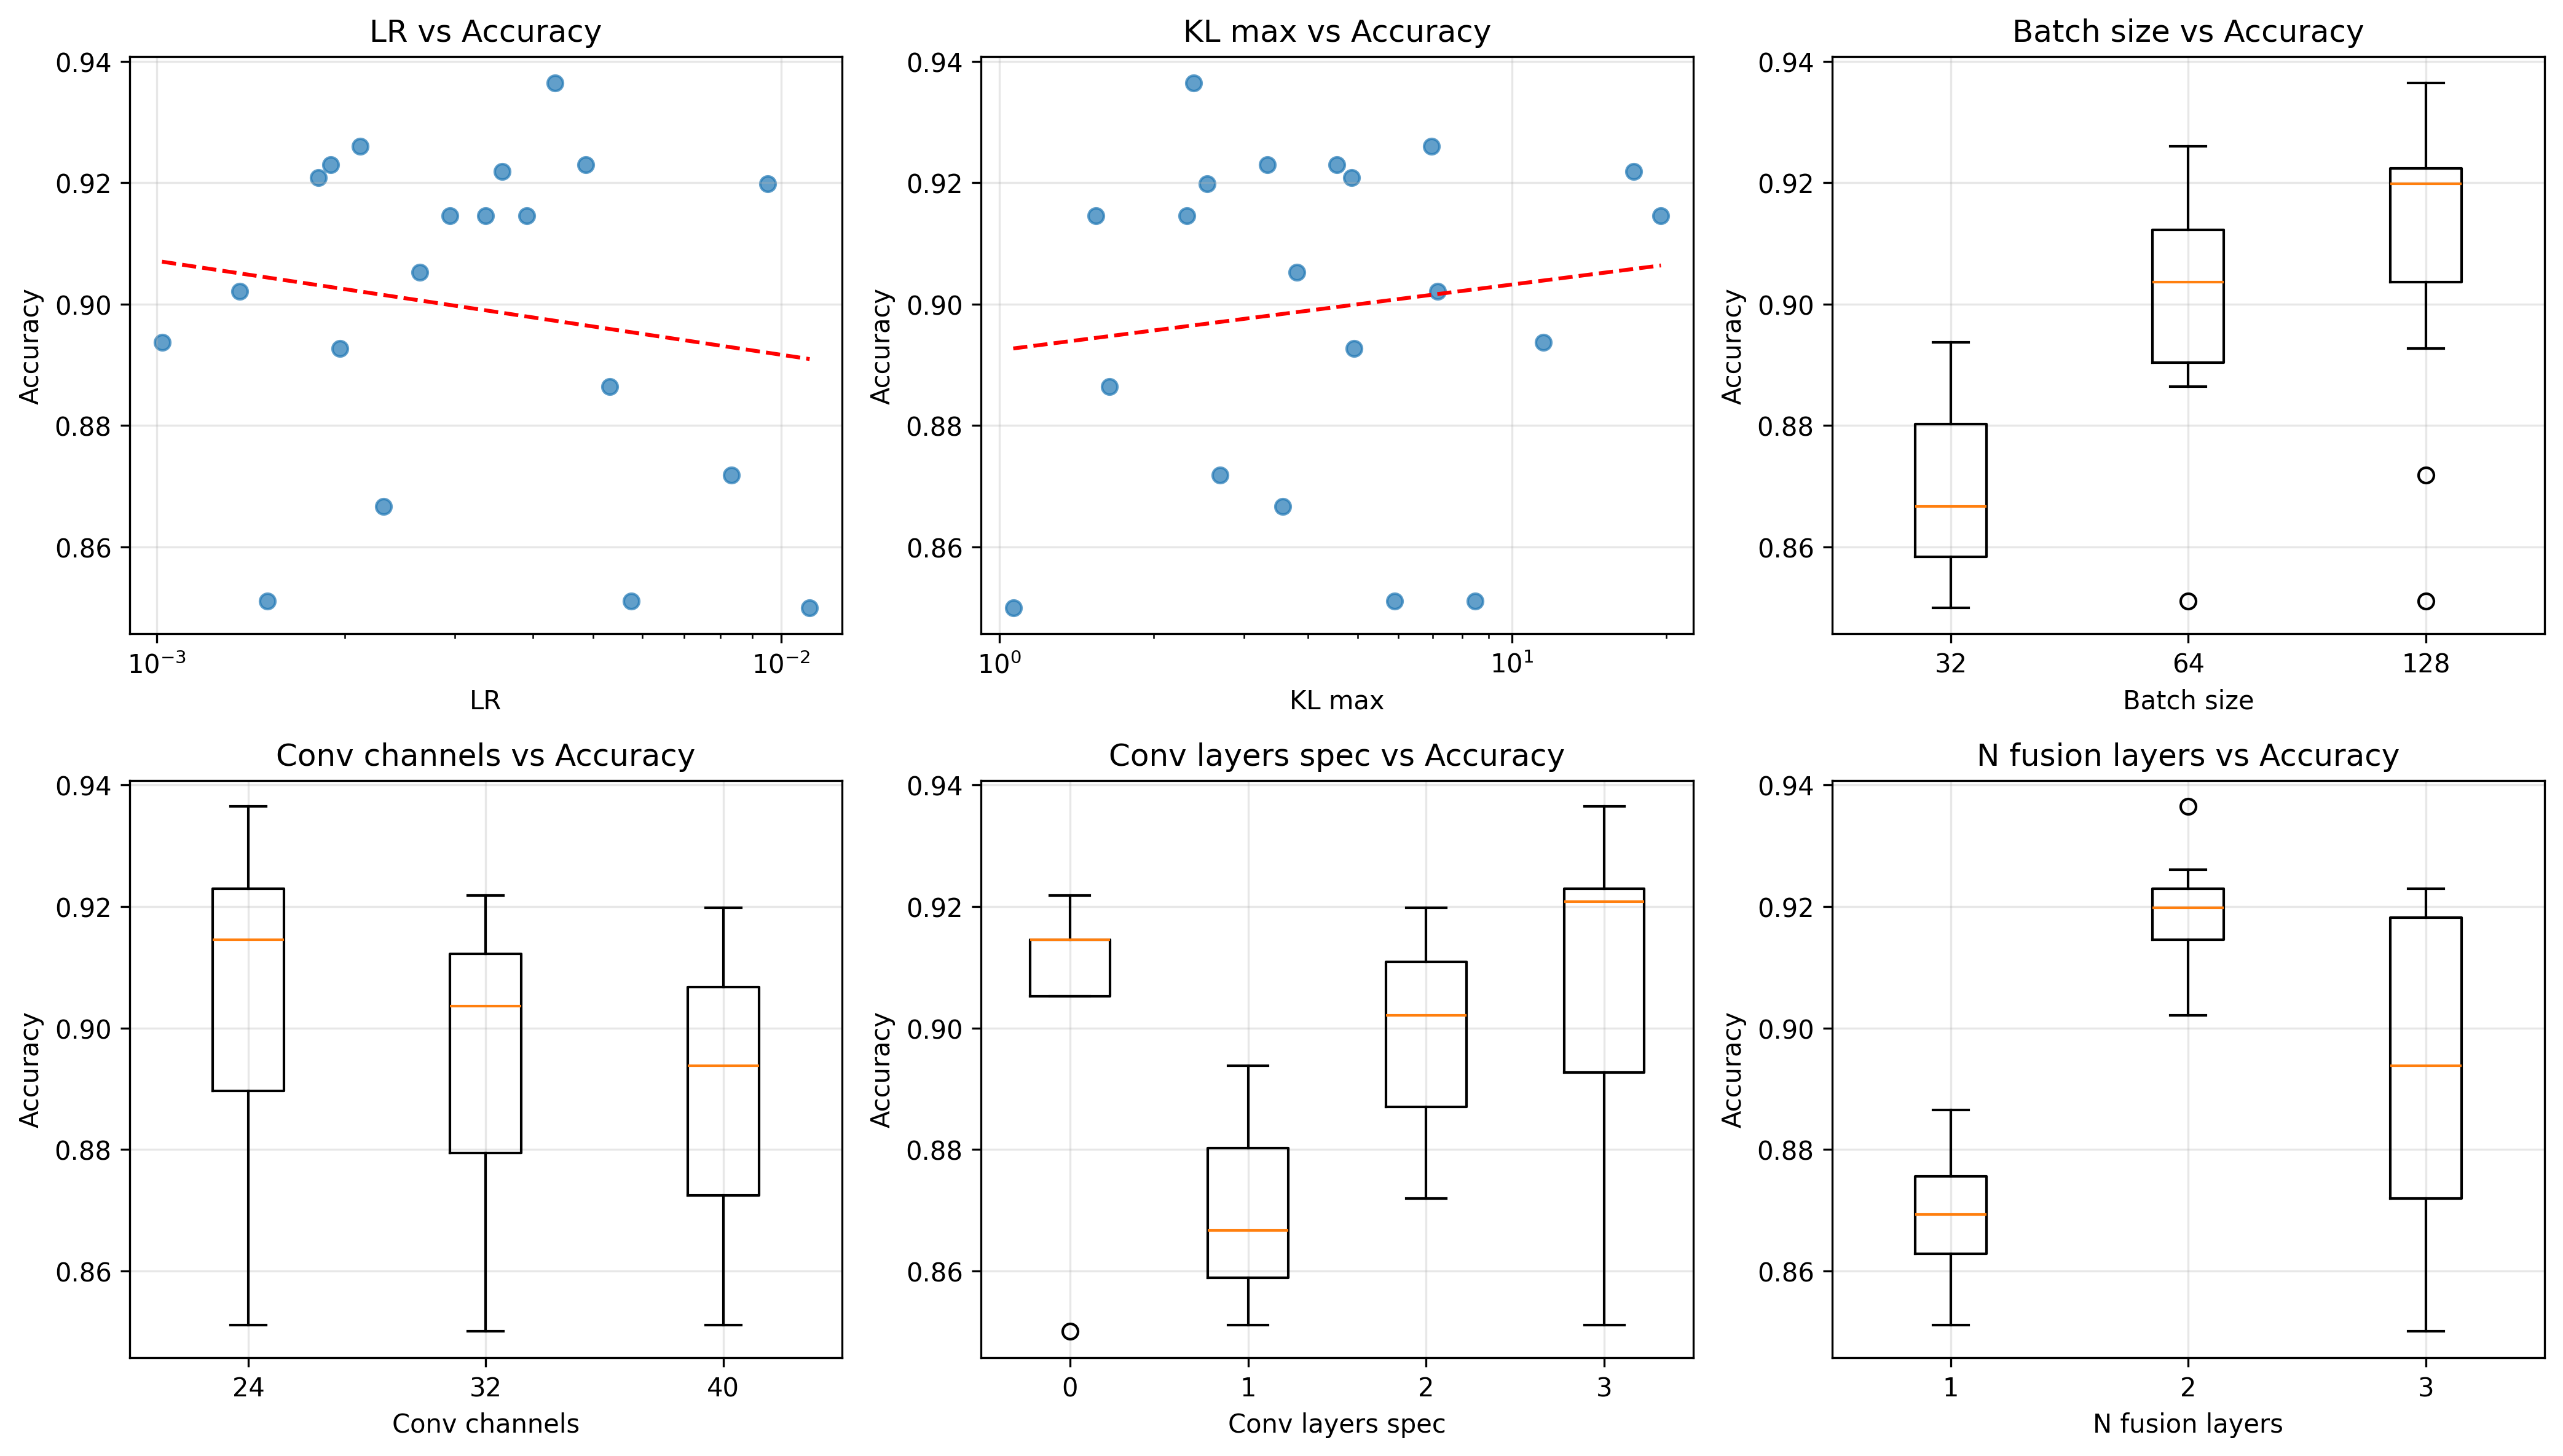

In [13]:
completed = study[study["state"] == "COMPLETE"].copy()

params = {
    "params_lr": ("LR", "continuous"),
    "params_kl_max": ("KL max", "continuous"),
    "params_batch_size": ("Batch size", "discrete"),
    "params_conv_channels": ("Conv channels", "discrete"),
    "params_conv_layers_spec": ("Conv layers spec", "discrete"),
    "params_n_fusion_layers": ("N fusion layers", "discrete"),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (col, (label, kind)) in zip(axes, params.items(), strict=True):
    if kind == "continuous":
        ax.scatter(completed[col], completed["value"], alpha=0.7)
        x = np.log10(completed[col])
        z = np.polyfit(x, completed["value"], 1)
        p = np.poly1d(z)
        x_sorted = np.sort(x)
        ax.plot(10**x_sorted, p(x_sorted), color="red", linewidth=1.5, linestyle="--")
        ax.set_xscale("log")
        ax.set_xlabel(label)
        ax.set_ylabel("Accuracy")
        ax.grid(alpha=0.3)
    else:
        groups = [grp["value"].values for _, grp in completed.groupby(col)]
        labels = sorted(completed[col].unique())
        ax.boxplot(groups, tick_labels=labels)
        ax.set_xlabel(label)
        ax.set_ylabel("Accuracy")
        ax.grid(alpha=0.3)

    ax.set_title(f"{label} vs Accuracy")

plt.tight_layout()
plt.show()

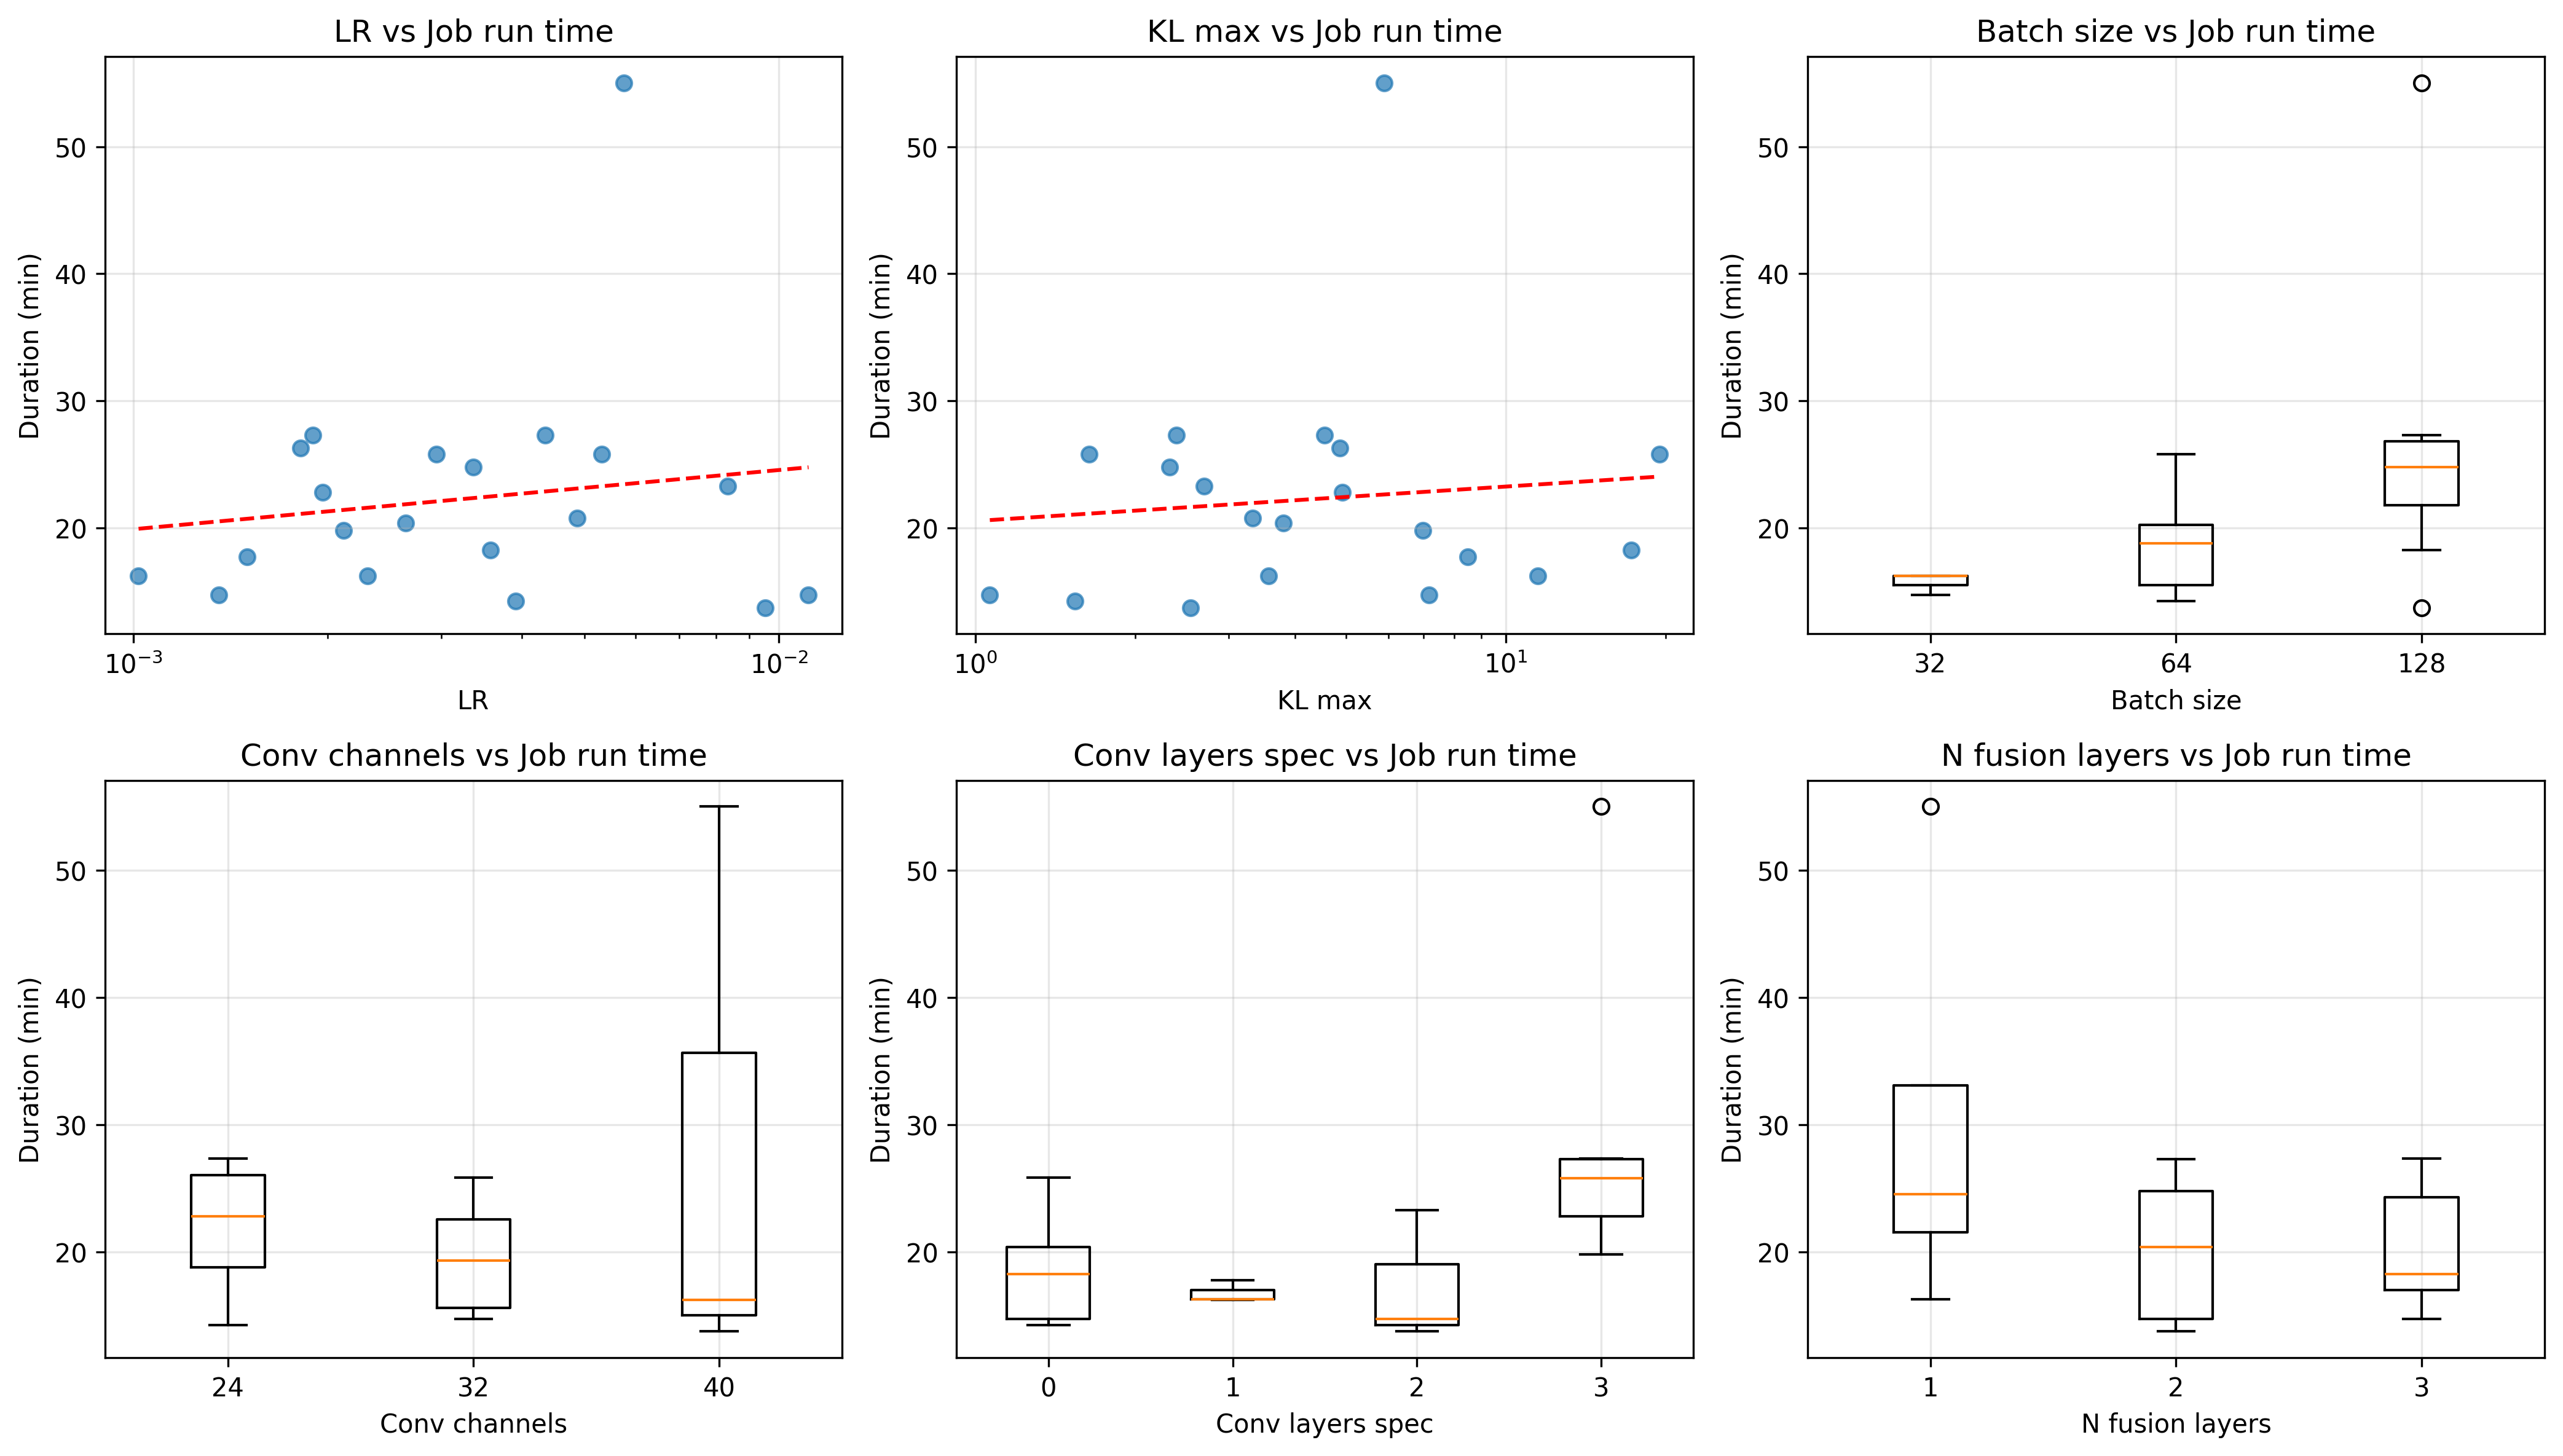

In [14]:
completed = study[study["state"] == "COMPLETE"].copy()
completed["duration_min"] = (
    (completed["datetime_complete"] - completed["datetime_start"])
    .dt.total_seconds() / 60
)

params = {
    "params_lr": ("LR", "continuous"),
    "params_kl_max": ("KL max", "continuous"),
    "params_batch_size": ("Batch size", "discrete"),
    "params_conv_channels": ("Conv channels", "discrete"),
    "params_conv_layers_spec": ("Conv layers spec", "discrete"),
    "params_n_fusion_layers": ("N fusion layers", "discrete"),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (col, (label, kind)) in zip(axes, params.items(), strict=True):
    if kind == "continuous":
        ax.scatter(completed[col], completed["duration_min"], alpha=0.7)
        x = np.log10(completed[col])
        z = np.polyfit(x, completed["duration_min"], 1)
        p = np.poly1d(z)
        x_sorted = np.sort(x)
        ax.plot(10**x_sorted, p(x_sorted), color="red", linewidth=1.5, linestyle="--")
        ax.set_xscale("log")
        ax.set_xlabel(label)
        ax.set_ylabel("Duration (min)")
        ax.grid(alpha=0.3)
    else:
        groups = [grp["duration_min"].values for _, grp in completed.groupby(col)]
        labels = sorted(completed[col].unique())
        ax.boxplot(groups, tick_labels=labels)
        ax.set_xlabel(label)
        ax.set_ylabel("Duration (min)")
        ax.grid(alpha=0.3)
    ax.set_title(f"{label} vs Job run time")

plt.tight_layout()
plt.show()

### Accuracy Distribution per Trial

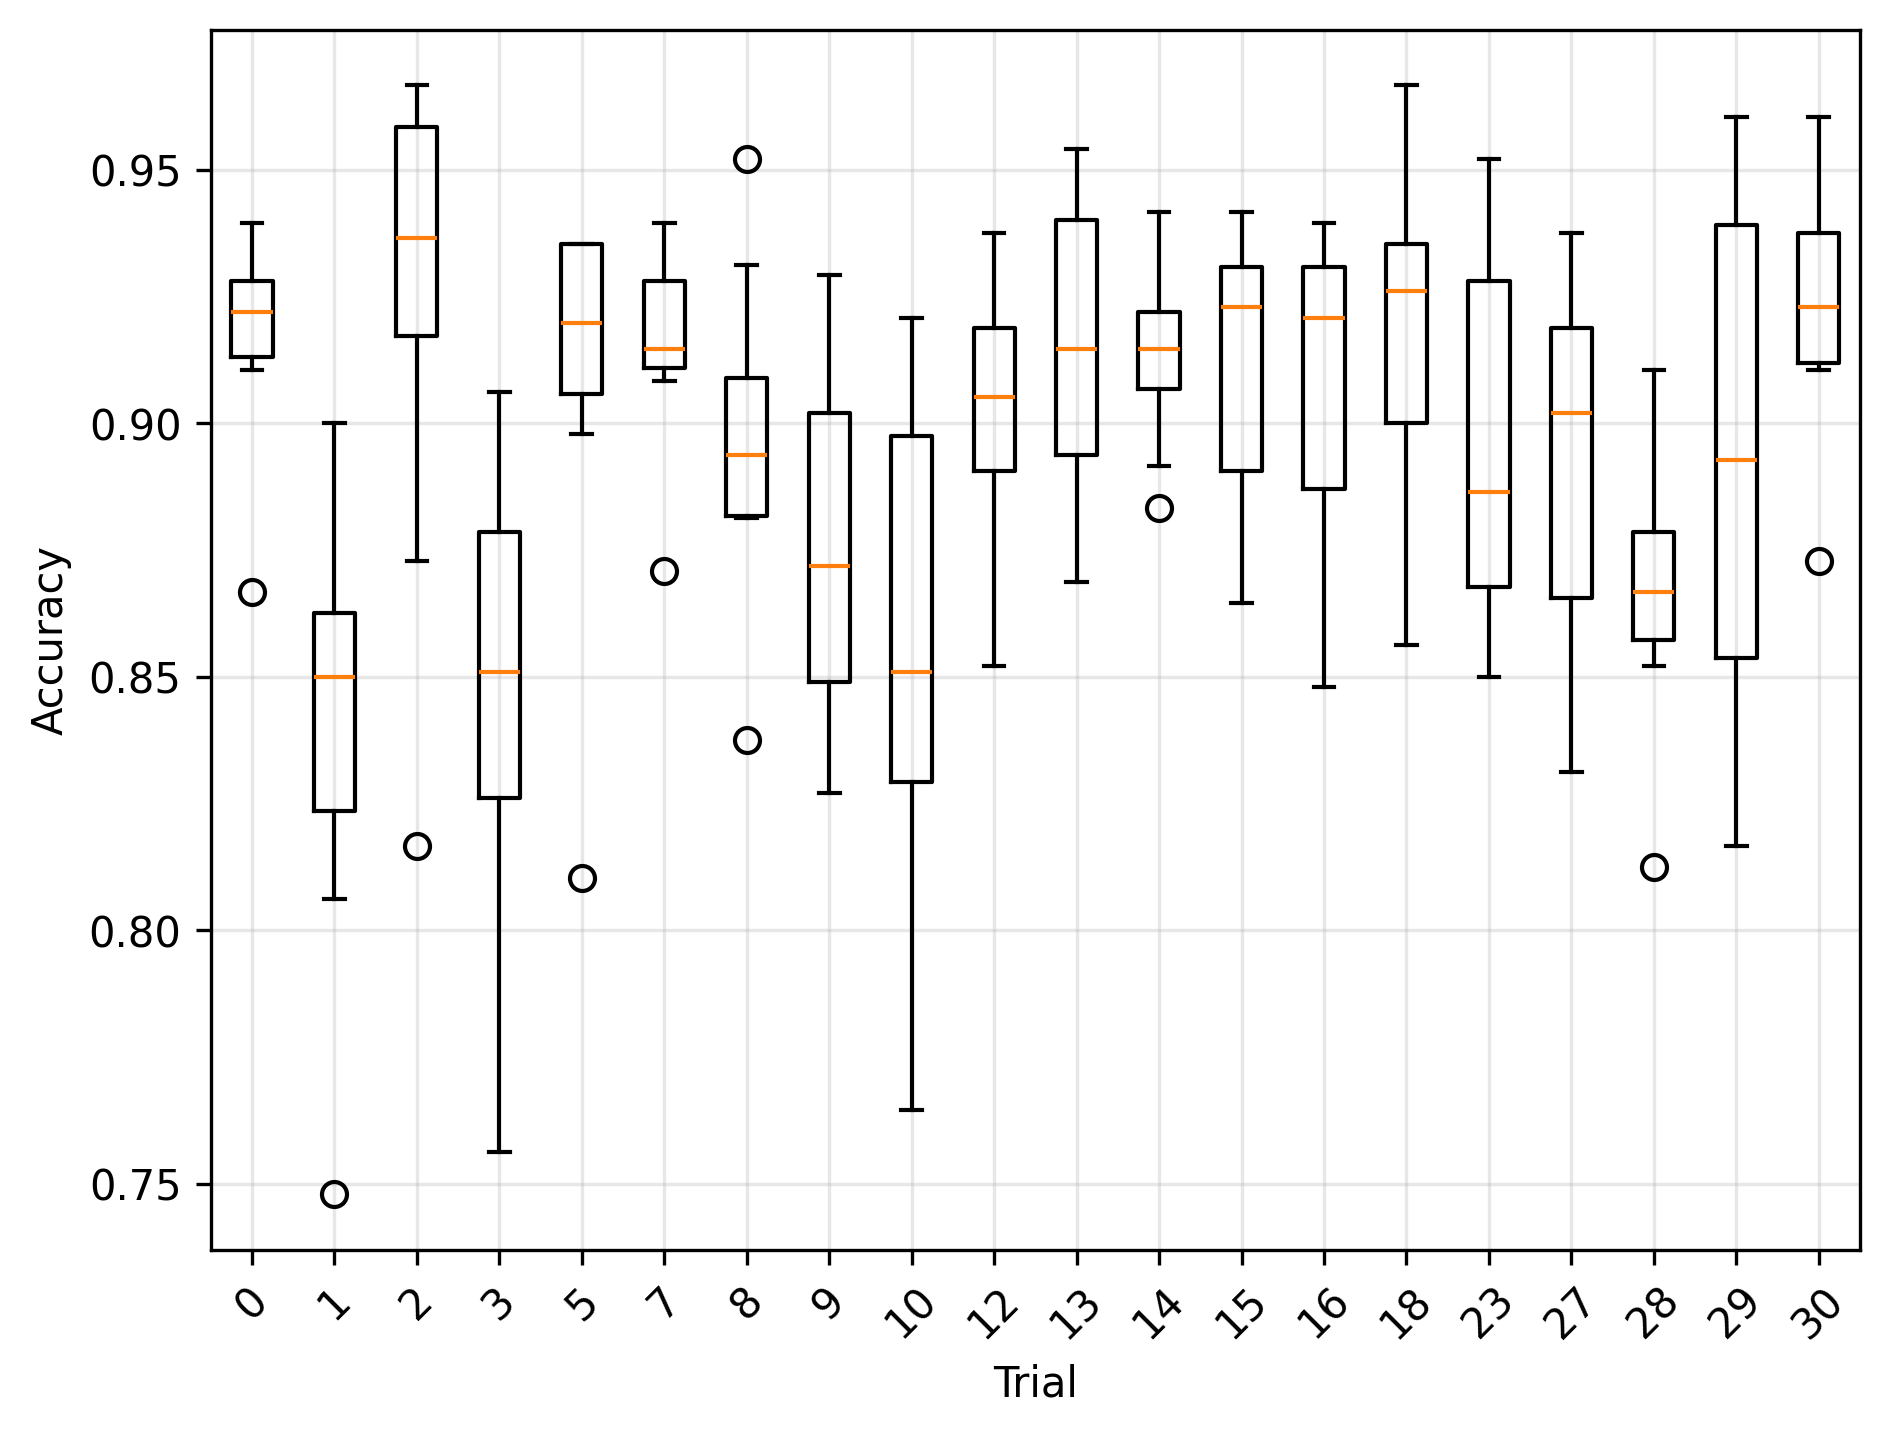

In [15]:
plt.boxplot(
    completed["user_attrs_accuracies"].apply(lambda x: list(x.values())),
    tick_labels=completed["number"].astype(int).tolist(),
)
plt.xlabel("Trial")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.tick_params(axis="x", rotation=45)

### Accuracy vs IQR (best trials: top-left)

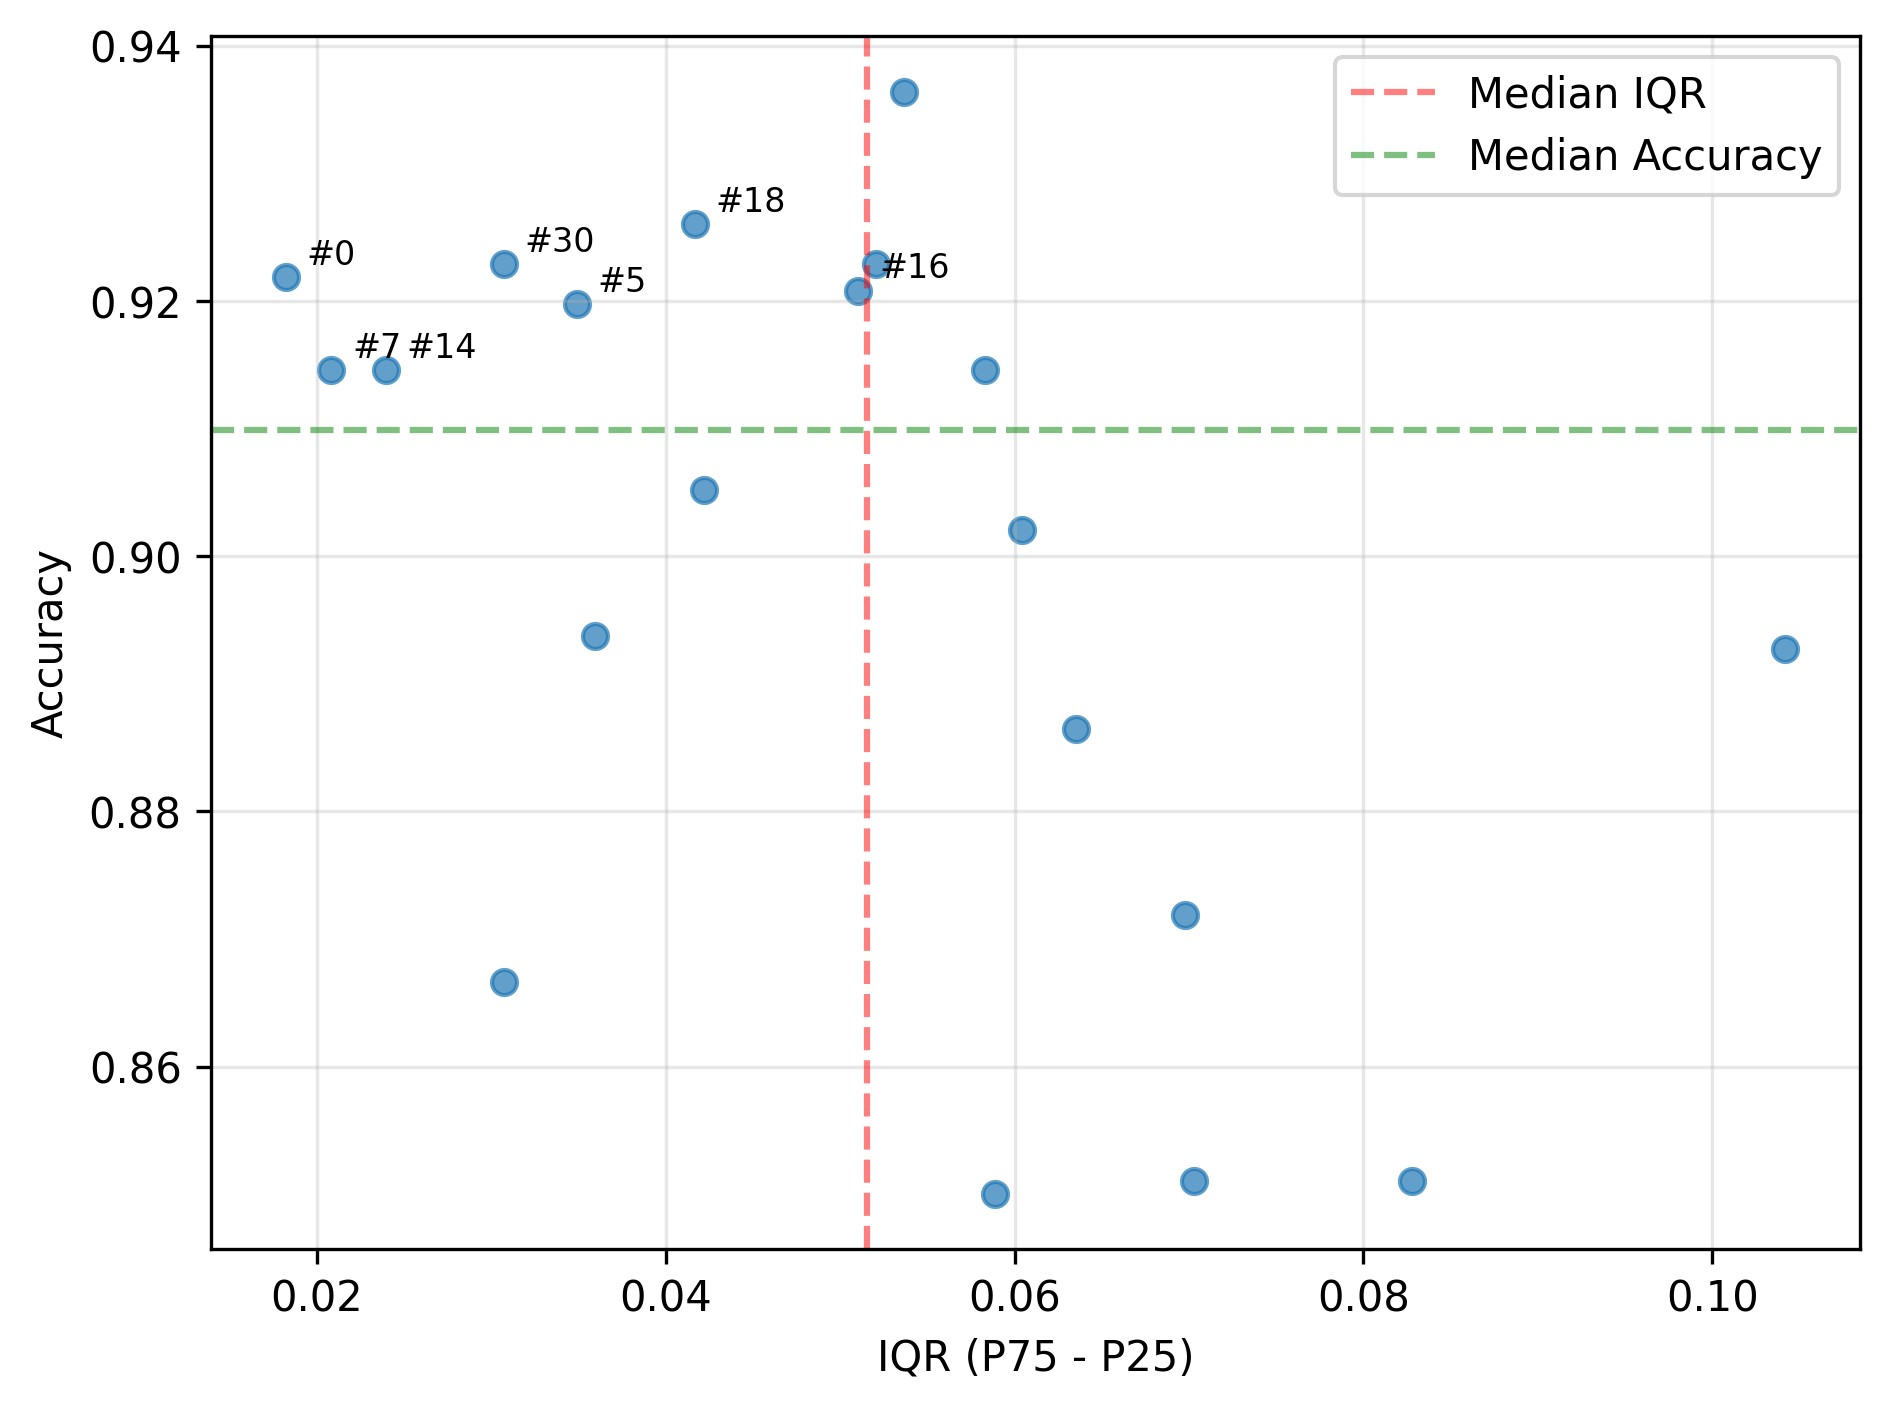

In [16]:
completed = study[study["state"] == "COMPLETE"].copy()
completed["iqr"] = completed["user_attrs_accuracy_p75"] - completed["user_attrs_accuracy_p25"]

sc = plt.scatter(completed["iqr"], completed["value"], alpha=0.7)
# annotate best trials (top-left quadrant)
thresh_iqr = completed["iqr"].median()
thresh_acc = completed["value"].median()
for _, row in completed[(completed["iqr"] < thresh_iqr) & (completed["value"] > thresh_acc)].iterrows():
    plt.annotate(
        f"#{int(row['number'])}",
        (row["iqr"], row["value"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=8,
    )
plt.axvline(thresh_iqr, color="red", linestyle="--", alpha=0.5, label="Median IQR")
plt.axhline(thresh_acc, color="green", linestyle="--", alpha=0.5, label="Median Accuracy")
plt.xlabel("IQR (P75 - P25)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()